# <span style='color:Red'>Misbinding models (Part 0.3)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, seaborn, pandas, pickle
from matplotlib import pyplot
from scipy.stats import vonmises

saveFigs = True
imagePath = 'img/models/'
imageFormats = ['svg','pdf']
exportsPathSensitivity = 'exports/biasModels/temp/biasFits/'
exportsPathCrossFits = 'exports/biasModels/temp/crossFitsFinal/'
exportsPathBICFits = 'exports/biasModels/temp/BICFitsFinal/'

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Model proposals</span>

In [2]:
_,binEdges = numpy.histogram(numpy.ones((1,1000))*numpy.pi/180,
                             bins=72,range=(-180,180),density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2

guessing,_ = numpy.histogram(binCenters,bins=72,density=True)
guessing = guessing*180/numpy.pi

kappa1 = 4
kappa2 = 3
kappa3 = 5

locationMB = 180/3

aBias = 1/3

modelPalette = seaborn.color_palette("tab10")

verticalLineHeight = [0,1]
maxYLimModelProposal = 1.25

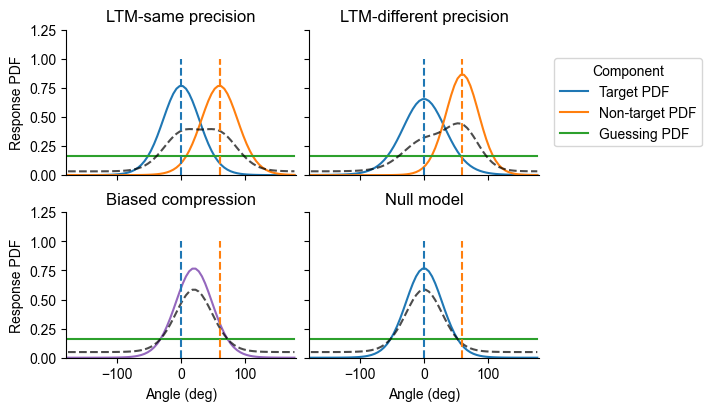

In [3]:
fig,ax = pyplot.subplots(2,3,figsize=(7,4),constrained_layout=True,
                         gridspec_kw={'width_ratios':[1.5,1.5,0.5],'height_ratios':[1,1],
                                      'wspace':0,'hspace':0},
                         sharex=True,sharey=True)

_,binEdges = numpy.histogram(numpy.ones((1,1000))*numpy.pi/180,
                             bins=72,range=(-180,180),density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2

guessing,_ = numpy.histogram(binCenters,bins=72,density=True)
guessing = guessing*180/numpy.pi

kappa1 = 4
kappa2 = 3
kappa3 = 5

locationMB = 180/3

aBias = 1/3

modelPalette = seaborn.color_palette("tab10")

verticalLineHeight = [0,1]
maxYLimModelProposal = 1.25

# Ax0[0,0]: MBSK
MBSKC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1)
MBSKC2 = vonmises.pdf(binCenters*numpy.pi/180,kappa1,loc=locationMB*numpy.pi/180)
MBSKFinal = 0.4*MBSKC1+0.4*MBSKC2+0.2*guessing
ax[0,0].plot(binCenters,MBSKC1,color=modelPalette[0],label='Target PDF')
ax[0,0].plot(binCenters,MBSKC2,color=modelPalette[1],label='Non-target PDF')
ax[0,0].plot(binCenters,guessing,color=modelPalette[2],label='Guessing PDF')
ax[0,0].plot(binCenters,MBSKFinal,color='black',linestyle='--',alpha=0.7)
ax[0,0].set_xlim(-180,180)
ax[0,0].set_ylim(0,maxYLimModelProposal)
ax[0,0].plot([0,0],verticalLineHeight,linestyle='--',color=modelPalette[0])
ax[0,0].plot([locationMB,locationMB],verticalLineHeight,linestyle='--',color=modelPalette[1])
ax[0,0].plot([locationMB,locationMB],verticalLineHeight,linestyle='--',color=modelPalette[1])
ax[0,0].set_ylabel('Response PDF')
ax[0,0].set_title('LTM-same precision')

# Ax0[0,1]: MBDK
MBDKC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa2)
MBDKC2 = vonmises.pdf(binCenters*numpy.pi/180,kappa3,loc=locationMB*numpy.pi/180)
MBDKFinal = 0.4*MBDKC1+0.4*MBDKC2+0.2*guessing
ax[0,1].plot(binCenters,MBDKC1,color=modelPalette[0])
ax[0,1].plot(binCenters,MBDKC2,color=modelPalette[1])
ax[0,1].plot(binCenters,guessing,color=modelPalette[2])
ax[0,1].plot(binCenters,MBDKFinal,color='black',linestyle='--',alpha=0.7)
ax[0,1].set_xlim(-180,180)
ax[0,1].set_ylim(0,maxYLimModelProposal)
ax[0,1].plot([0,0],verticalLineHeight,linestyle='--',color=modelPalette[0])
ax[0,1].plot([locationMB,locationMB],verticalLineHeight,linestyle='--',color=modelPalette[1])
ax[0,1].set_title('LTM-different precision')

# Ax0[1,0]: Bias
BiasC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1,loc=aBias*locationMB*numpy.pi/180)
BiasFinal = 0.7*BiasC1+0.3*guessing
ax[1,0].plot(binCenters,BiasC1,color=modelPalette[4],label='Biased PDF')
ax[1,0].plot(binCenters,guessing,color=modelPalette[2])
ax[1,0].plot(binCenters,BiasFinal,color='black',linestyle='--',alpha=0.7,label='Model PDF')
ax[1,0].set_xlim(-180,180)
ax[1,0].set_ylim(0,maxYLimModelProposal)
ax[1,0].plot([0,0],verticalLineHeight,linestyle='--',color=modelPalette[0])
ax[1,0].plot([locationMB,locationMB],verticalLineHeight,linestyle='--',color=modelPalette[1])
ax[1,0].set_ylabel('Response PDF')
ax[1,0].set_xlabel('Angle (deg)')
ax[1,0].set_title('Biased compression')

# Ax0[1,1]: NMB
NMBC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1)
NMBFinal = 0.7*NMBC1+0.3*guessing
ax[1,1].plot(binCenters,NMBC1,color=modelPalette[0])
ax[1,1].plot(binCenters,guessing,color=modelPalette[2])
ax[1,1].plot(binCenters,NMBFinal,color='black',linestyle='--',alpha=0.7)
ax[1,1].set_xlim(-180,180)
ax[1,1].set_ylim(0,maxYLimModelProposal)
ax[1,1].plot([0,0],verticalLineHeight,linestyle='--',color=modelPalette[0])
ax[1,1].plot([locationMB,locationMB],verticalLineHeight,linestyle='--',color=modelPalette[1])
ax[1,1].set_xlabel('Angle (deg)')
ax[1,1].set_title('Null model')

ax[0,2].axis('off')
ax[1,2].axis('off')

handles1,labels1 = ax[0,0].get_legend_handles_labels()
handles2,labels2= ax[1,1].get_legend_handles_labels()
ax[0,2].legend(handles=handles1+handles2,labels=labels1+labels2,title='Component',loc='center left')

seaborn.set_style('ticks')
seaborn.despine()

# if (saveFigs):
#     for format in imageFormats:
#         fig.savefig(imagePath+'modelProposal_p1.'+format,format=format,dpi=1200)

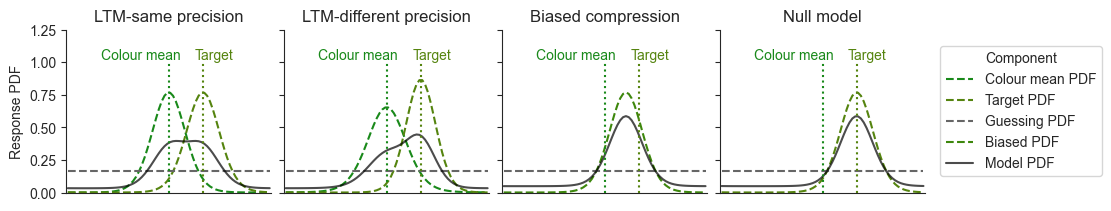

In [4]:
fig,ax = pyplot.subplots(1,5,figsize=(11,2),constrained_layout=True,
                         gridspec_kw={'width_ratios':[1.5,1.5,1.5,1.5,0.5],
                                      'wspace':0,'hspace':0},
                         sharex=True,sharey=True)

_,binEdges = numpy.histogram(numpy.ones((1,1000))*numpy.pi/180,
                             bins=72,range=(-180,180),density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2

guessing,_ = numpy.histogram(binCenters,bins=72,density=True)
guessing = guessing*180/numpy.pi

kappa1 = 4
kappa2 = 3
kappa3 = 5

locationMB = 180/3

aBias = 5/8

modelPalette = seaborn.color_palette("tab10")
modelPalette = ["#19891A","#55840F","#666666","#000000","#3D870C"]

verticalLineHeight = [0,1]
maxYLimModelProposal = 1.25

# Ax0[0,0]: MBSK
MBSKC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1)
MBSKC2 = vonmises.pdf(binCenters*numpy.pi/180,kappa1,loc=locationMB*numpy.pi/180)
MBSKFinal = 0.4*MBSKC1+0.4*MBSKC2+0.2*guessing
ax[0].plot(binCenters,MBSKC1,color=modelPalette[0],linestyle='--',label='Colour mean PDF')
ax[0].plot(binCenters,MBSKC2,color=modelPalette[1],linestyle='--',label='Target PDF')
ax[0].plot(binCenters,guessing,color=modelPalette[2],linestyle='--',label='Guessing PDF')
ax[0].plot(binCenters,MBSKFinal,color='black',alpha=0.7)
ax[0].set_xlim(-180,180)
ax[0].set_ylim(0,maxYLimModelProposal)
ax[0].plot([0,0],verticalLineHeight,linestyle=':',color=modelPalette[0])
ax[0].plot([locationMB,locationMB],verticalLineHeight,linestyle=':',color=modelPalette[1])
ax[0].text(-120,1.02,'Colour mean',rotation=0,color=modelPalette[0])
ax[0].text(locationMB-15,1.02,'Target',rotation=0,color=modelPalette[1])
ax[0].set_xlabel('')
ax[0].set_xticks([])
ax[0].set_ylabel('Response PDF')
ax[0].set_title('LTM-same precision')

# Ax0[0,1]: MBDK
MBDKC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa2)
MBDKC2 = vonmises.pdf(binCenters*numpy.pi/180,kappa3,loc=locationMB*numpy.pi/180)
MBDKFinal = 0.4*MBDKC1+0.4*MBDKC2+0.2*guessing
ax[1].plot(binCenters,MBDKC1,color=modelPalette[0],linestyle='--')
ax[1].plot(binCenters,MBDKC2,color=modelPalette[1],linestyle='--')
ax[1].plot(binCenters,guessing,color=modelPalette[2],linestyle='--')
ax[1].plot(binCenters,MBDKFinal,color='black',alpha=0.7)
ax[1].set_xlim(-180,180)
ax[1].set_ylim(0,maxYLimModelProposal)
ax[1].plot([0,0],verticalLineHeight,linestyle=':',color=modelPalette[0])
ax[1].plot([locationMB,locationMB],verticalLineHeight,linestyle=':',color=modelPalette[1])
ax[1].text(-120,1.02,'Colour mean',rotation=0,color=modelPalette[0])
ax[1].text(locationMB-15,1.02,'Target',rotation=0,color=modelPalette[1])
ax[1].set_title('LTM-different precision')
ax[1].set_xlabel('')

# Ax0[1,0]: Bias
BiasC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1,loc=aBias*locationMB*numpy.pi/180)
BiasFinal = 0.7*BiasC1+0.3*guessing
ax[2].plot(binCenters,BiasC1,color=modelPalette[4],linestyle='--',label='Biased PDF')
ax[2].plot(binCenters,guessing,color=modelPalette[2],linestyle='--')
ax[2].plot(binCenters,BiasFinal,color='black',alpha=0.7,label='Model PDF')
ax[2].set_xlim(-180,180)
ax[2].set_ylim(0,maxYLimModelProposal)
ax[2].plot([0,0],verticalLineHeight,linestyle=':',color=modelPalette[0])
ax[2].plot([locationMB,locationMB],verticalLineHeight,linestyle=':',color=modelPalette[1])
ax[2].text(-120,1.02,'Colour mean',rotation=0,color=modelPalette[0])
ax[2].text(locationMB-15,1.02,'Target',rotation=0,color=modelPalette[1])
# ax[2].set_ylabel('Response PDF')
ax[2].set_xlabel('')
ax[2].set_title('Biased compression')

# Ax0[1,1]: NMB
NMBC1 = vonmises.pdf(binCenters*numpy.pi/180,kappa1,loc=locationMB*numpy.pi/180)
NMBFinal = 0.7*NMBC1+0.3*guessing
ax[3].plot(binCenters,NMBC1,color=modelPalette[1],linestyle='--')
ax[3].plot(binCenters,guessing,color=modelPalette[2],linestyle='--')
ax[3].plot(binCenters,NMBFinal,color='black',alpha=0.7)
ax[3].set_xlim(-180,180)
ax[3].set_ylim(0,maxYLimModelProposal)
ax[3].plot([0,0],verticalLineHeight,linestyle=':',color=modelPalette[0])
ax[3].plot([locationMB,locationMB],verticalLineHeight,linestyle=':',color=modelPalette[1])
ax[3].text(-120,1.02,'Colour mean',rotation=0,color=modelPalette[0])
ax[3].text(locationMB-15,1.02,'Target',rotation=0,color=modelPalette[1])
ax[3].set_xlabel('')
ax[3].set_title('Null model')

ax[4].axis('off')

handles1,labels1 = ax[0].get_legend_handles_labels()
handles2,labels2= ax[2].get_legend_handles_labels()
ax[4].legend(handles=handles1+handles2,labels=labels1+labels2,title='Component',loc='center left')

seaborn.set_style('ticks')
seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'modelProposal_p1.'+format,format=format,dpi=1200)

In [5]:
dfToSave = pandas.read_csv(exportsPathCrossFits+"finalMatrix.csv",index_col='Recovered model')

spmMatrix = numpy.zeros((4,4))

counter = 0
for model in range(4):
    exec(f'readDF = pandas.read_csv(exportsPathBICFits+"modelsTrainBIC_SPMBSM_df{model}.csv")')
    spmMatrix[counter,:] = numpy.array([readDF["xp_MBSK"],readDF["xp_MBDK"],readDF["xp_Bias"],readDF["xp_NMB"]]).flatten()
    counter += 1

dataToSaveSPM = {'Recovered model':['LTM-same\nprecision','LTM-different\nprecision','Biased','Null'],
                 'LTM-same\nprecision':spmMatrix[0,:],
                 'LTM-different\nprecision':spmMatrix[1,:],
                 'Biased':spmMatrix[2,:],
                 'Null':spmMatrix[3,:]}

dfToSaveSPM = pandas.DataFrame.from_dict(dataToSaveSPM)
dfToSaveSPM.set_index('Recovered model',inplace=True)

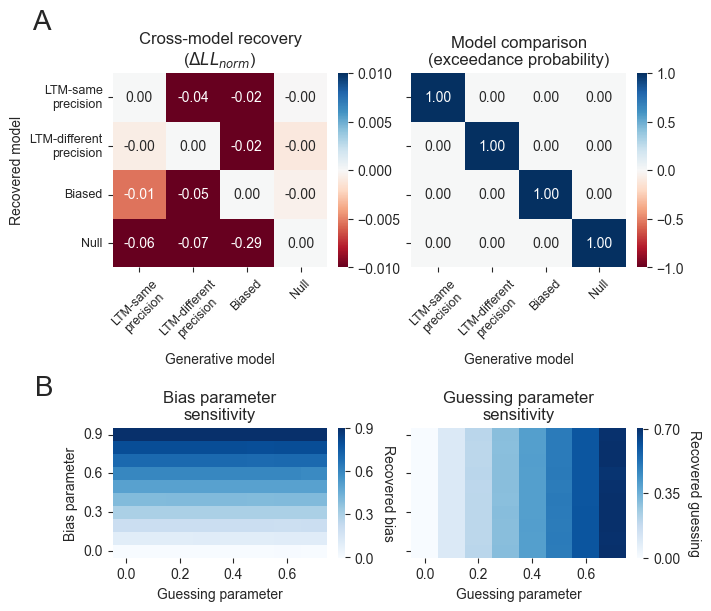

In [6]:
fig,ax = pyplot.subplot_mosaic([['A','B'],['C','D']],figsize=(7,6),constrained_layout=True,
                               gridspec_kw={'height_ratios':[1.5,1],'wspace':0})

# Ax1[A]: cross-model recovery performance
modelRecoveryDF = dfToSave
seaborn.heatmap(ax=ax['A'],data=modelRecoveryDF,annot=True,fmt='.2f',cmap='RdBu',vmax=0.01,vmin=-0.01)
ax['A'].set_title('Cross-model recovery\n($\Delta LL_{norm}$)')
ax['A'].set_xlabel('Generative model')
ax['A'].set_xticklabels(modelRecoveryDF.columns.str.replace("\\n","\n",regex=False),rotation=45,fontsize=9)
ax['A'].set_yticklabels(modelRecoveryDF.index.str.replace("\\n","\n",regex=False),rotation=0,fontsize=9)
ax['A'].text(-1.5,-0.9,'A',fontsize=20)

# Ax1[B]: SPM recovery performance
modelComparisonDF = dfToSaveSPM
seaborn.heatmap(ax=ax['B'],data=modelComparisonDF,annot=True,fmt='.2f',cmap='RdBu',vmax=1,vmin=-1)
ax['B'].set_title('Model comparison\n(exceedance probability)')
ax['B'].set_xlabel('Generative model')
ax['B'].set_ylabel("")
ax['B'].set_xticklabels(modelComparisonDF.columns.str.replace("\\n","\n",regex=False),rotation=45,fontsize=9)
ax['B'].set_yticklabels("")
# ax['B'].text(-0.5,-0.9,'B',fontsize=20)

# Ax1[C]: bias model sensitivity analysis (bias)
with open(exportsPathSensitivity+'biasData.pkl','rb') as fp:
        biasData = pickle.load(fp)
seaborn.heatmap(ax=ax['C'],data=biasData['data'],cmap='Blues',xticklabels=biasData['x'],yticklabels=biasData['y'])
ax['C'].set_ylabel('Bias parameter')
ax['C'].set_xlabel('Guessing parameter')
ax['C'].set_title('Bias parameter\nsensitivity')
ax['C'].set_yticks(numpy.arange(0,10,3)+0.5,labels=[f'{i:.1f}' for i in numpy.flip(numpy.arange(0,1,0.3))])
ax['C'].set_xticks(numpy.arange(0,8,2)+0.5,labels=[f'{i:.1f}' for i in numpy.arange(0,0.8,0.2)])
ax['C'].text(-2.9,-2.55,'B',fontsize=20)
ax['C'].collections[0].colorbar.set_ticks([0,0.3,0.6,0.9])
ax['C'].collections[0].colorbar.set_label("Recovered bias",rotation=270,labelpad=15)

# Ax1[D]: bias model sensitivity analysis (guessing)
with open(exportsPathSensitivity+'guessingData.pkl','rb') as fp:
        guessingData = pickle.load(fp)
seaborn.heatmap(ax=ax['D'],data=guessingData['data'],cmap='Blues',xticklabels=guessingData['x'],yticklabels=guessingData['y'])
ax['D'].set_ylabel('')
ax['D'].set_xlabel('Guessing parameter')
ax['D'].set_title('Guessing parameter\nsensitivity')
ax['D'].set_yticks(numpy.arange(0,10,3)+0.5,labels=[f'{i:.1f}' for i in numpy.flip(numpy.arange(0,1,0.3))])
ax['D'].set_yticklabels('')
ax['D'].set_xticks(numpy.arange(0,8,2)+0.5,labels=[f'{i:.1f}' for i in numpy.arange(0,0.8,0.2)])
ax['D'].collections[0].colorbar.set_ticks([0,0.35,0.7])
ax['D'].collections[0].colorbar.set_label("Recovered guessing",rotation=270,labelpad=15)

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'modelProposal_p2.'+format,format=format,dpi=1200)